# Instrumental Variables

## IV example on mock dataset

### Constructing the dataset

Create four random series of length $N=100000$

- $x$: education
- $y$: salary
- $z$: ambition
- $q$: early smoking 

such that:

1. $x$ and $z$ cause $y$
2. $z$ causes $x$
3. $q$ is correlated with $x$, not with $z$


A problem arises when the confounding factor $z$ is not observed. In that case, we can estimate the direct effect of $x$ on $y$ by using $q$ as an instrument.

Run the following code to create a mock dataset.

In [1]:
import numpy as np
import pandas as pd

In [2]:
N = 100000
ϵ_z = np.random.randn(N)*0.1
ϵ_x = np.random.randn(N)*0.1
ϵ_q = np.random.randn(N)*0.01
ϵ_y = np.random.randn(N)*0.01

In [3]:
z = 0.1 + ϵ_z
q = 0.5 + 0.1234*ϵ_x + ϵ_q
# q affects x (so q is correlated with x)
x = 0.1 + z + q + ϵ_x
# The true model: y depends on x (coef 0.9) and z (coef 0.4)
y = 1.0 + 0.9*x + 0.4*z + ϵ_y

In [4]:
df = pd.DataFrame({
    "x": x,
    "y": y,
    "z": z,
    "q": q
})

**Describe the dataframe. Compute the correlations between the variables. Are they compatible with the hypotheses for IV?**

In [5]:
df.head(10)

,x,y,z,q
0,0.891627,1.879862,0.222379,0.505966
1,0.646968,1.617677,0.046017,0.501911
2,0.767252,1.731994,0.099797,0.502470
3,0.906449,1.948339,0.293565,0.500542
4,0.808983,1.767842,0.124570,0.503468
5,0.691020,1.704424,0.198258,0.483160
6,0.681519,1.648863,0.106403,0.493194
7,0.788880,1.710041,-0.019510,0.522710
8,0.830424,1.834433,0.237720,0.506156
9,0.598086,1.539929,0.022057,0.503226


In [6]:
df.describe()

,x,y,z,q
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.700580,1.670696,0.100522,0.499998
std,0.150942,0.165339,0.099674,0.015916
min,0.058520,0.942927,-0.325242,0.426389
25%,0.598991,1.559574,0.033057,0.489252
50%,0.700441,1.670870,0.101047,0.499943
75%,0.801745,1.782408,0.167774,0.510733
max,1.374939,2.407125,0.524792,0.575849


In [7]:
df.corr()

,x,y,z,q
x,1.000000,0.981753,0.663416,0.622857
y,0.981753,1.000000,0.786215,0.512235
z,0.663416,0.786215,1.000000,0.001524
q,0.622857,0.512235,0.001524,1.000000


**What to look for in the correlation table:**

- `cor(q, x)` should be non-zero → the instrument is **relevant** (it predicts x).
- `cor(q, z)` should be close to zero → the instrument is **exogenous** (it does not directly affect y through z).

These two conditions (relevance + exogeneity) are needed for a valid instrument.

### OLS Regression

Use `linearmodels` to run a regression estimating the effect of $x$ on $y$.

**Note:** `linearmodels` has a slightly different API than `statsmodels`. We call `.fit()` and then display the result directly (no `.summary()` needed).

In [8]:
from linearmodels import OLS, IV2SLS

In [10]:
model = OLS.from_formula("y ~ x", df)
res = model.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:                      y   R-squared:                      0.9638
Estimator:                        OLS   Adj. R-squared:                 0.9638
No. Observations:              100000   F-statistic:                 2.678e+06
Date:                Sun, Mar 01 2026   P-value (F-stat)                0.0000
Time:                        16:07:11   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      0.9173     0.0005     1946.8     0.0000      0.9164      0.9182
x              1.0754     0.0007     1636.3     0.00

**Interpretation:**

The regression is globally very significant (p-value < 0.001) and R² is very high.

However, the coefficient on $x$ is **not** 0.9 (the true value). It is biased upward because $z$ (ambition) affects both $x$ and $y$ but is omitted from the regression. This is called **omitted variable bias**.

**Assume briefly that `z` is known and control the regression by `z`. What happens?**

In [12]:
model = OLS.from_formula("y ~ x + z", df)
res = model.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:                      y   R-squared:                      0.9963
Estimator:                        OLS   Adj. R-squared:                 0.9963
No. Observations:              100000   F-statistic:                 2.732e+07
Date:                Sun, Mar 01 2026   P-value (F-stat)                0.0000
Time:                        16:07:45   Distribution:                  chi2(2)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      0.9998     0.0002     5759.0     0.0000      0.9994      1.0001
x              0.9003     0.0003     3216.8     0.00

**Interpretation:** Now the coefficient on $x$ is approximately 0.9 and the coefficient on $z$ is approximately 0.4. These match the true model (`y = 1.0 + 0.9*x + 0.4*z`). Controlling for the confounding variable fixes the bias.

But in practice, we often **cannot observe** the confounding variable. That is why we need instrumental variables.

### Instrumental variable

Now we pretend that `z` is unobserved. We use $q$ as an instrument to estimate the causal effect of $x$ on $y$.

**Why does this work?** Because $q$ is correlated with $x$ (relevance) but is not correlated with $z$ (exogeneity). So $q$ gives us variation in $x$ that is "clean" — not contaminated by the confounding factor.

Use $q$ to instrument the effect of $x$ on $y$.

In `linearmodels`, the IV formula syntax is: `"y ~ 1 + [x ~ q]"` where `[x ~ q]` means "instrument x with q".

In [13]:
formula = "y ~ 1 + [x ~ q]"
mod = IV2SLS.from_formula(formula, df)
res = mod.fit()
print(res)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                      y   R-squared:                      0.9384
Estimator:                    IV-2SLS   Adj. R-squared:                 0.9384
No. Observations:              100000   F-statistic:                 4.268e+05
Date:                Sun, Mar 01 2026   P-value (F-stat)                0.0000
Time:                        16:09:08   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      1.0396     0.0010     1065.7     0.0000      1.0377      1.0415
x              0.9008     0.0014     653.32     0.00

**Interpretation:** The IV estimate of the coefficient on $x$ is approximately 0.9 — the correct value! This is impressive because we did **not** have access to the confounding variable $z$. Instead, we used the instrument $q$ to isolate the causal effect of $x$ on $y$.

---

## Return on Education

We follow the excellent R [tutorial](https://www.econometrics-with-r.org/12-6-exercises-10.html) from the *Econometrics with R* book.

The goal is to measure the effect of schooling on earnings, while correcting the endogeneity bias by using distance to college as an instrument.

**Download the college distance dataset with `statsmodels`. Describe the dataset and extract the dataframe.**

https://vincentarelbundock.github.io/Rdatasets/datasets.html

In [14]:
import statsmodels.api as sm
ds = sm.datasets.get_rdataset("CollegeDistance", "AER")

In [15]:
# Print the dataset documentation to understand what each variable means
print(ds.__doc__[:1500])  # print first part of the description

.. container::

   .. container::

      =============== ===============
      CollegeDistance R Documentation
      =============== ===============

      .. rubric:: College Distance Data
         :name: college-distance-data

      .. rubric:: Description
         :name: description

      Cross-section data from the High School and Beyond survey
      conducted by the Department of Education in 1980, with a follow-up
      in 1986. The survey included students from approximately 1,100
      high schools.

      .. rubric:: Usage
         :name: usage

      .. code:: R

         data("CollegeDistance")

      .. rubric:: Format
         :name: format

      A data frame containing 4,739 observations on 14 variables.

      gender
         factor indicating gender.

      ethnicity
         factor indicating ethnicity (African-American, Hispanic or
         other).

      score
         base year composite test score. These are achievement tests
         given to high school seniors

In [16]:
df = ds.data  # extract the dataframe from the dataset object

In [17]:
df.head()

,gender,ethnicity,score,fcollege,mcollege,home,urban,unemp,wage,distance,tuition,education,income,region
rownames,,,,,,,,,,,,,,
1,male,other,39.150002,yes,no,yes,yes,6.2,8.09,0.2,0.88915,12,high,other
2,female,other,48.869999,no,no,yes,yes,6.2,8.09,0.2,0.88915,12,low,other
3,male,other,48.740002,no,no,yes,yes,6.2,8.09,0.2,0.88915,12,low,other
4,male,afam,40.400002,no,no,yes,yes,6.2,8.09,0.2,0.88915,12,low,other
5,female,other,40.480000,no,no,no,yes,5.6,8.09,0.4,0.88915,13,low,other


In [38]:
print("Shape:", df.shape)
df.describe()

Shape: (4739, 15)


,score,unemp,wage,distance,tuition,education,income_binary
count,4739.000000,4739.000000,4739.000000,4739.000000,4739.000000,4739.000000,4739.000000
mean,50.889029,7.597215,9.500506,1.802870,0.814608,13.807765,0.288035
std,8.701910,2.763581,1.343067,2.297128,0.339504,1.789107,0.452895
min,28.950001,1.400000,6.590000,0.000000,0.257510,12.000000,0.000000
25%,43.924999,5.900000,8.850000,0.400000,0.484990,12.000000,0.000000
50%,51.189999,7.100000,9.680000,1.000000,0.824480,13.000000,0.000000
75%,57.769999,8.900000,10.150000,2.500000,1.127020,16.000000,1.000000
max,72.809998,24.900000,12.960000,20.000000,1.404160,18.000000,1.000000


**How is `income` encoded? Create a binary variable `income_binary` to replace it.**

The `income` column contains text values ("high" or "low"). We need a numeric version (1 or 0) to use it in a regression.

In [37]:
# Check the unique values
df['income'].unique()

array(['high', 'low'], dtype=object)

In [20]:
# Create a binary variable: 1 if income is "high", 0 otherwise
df['income_binary'] = (df['income'] == 'high') * 1.0

In [21]:
# Verify the new column
df['income_binary'].value_counts()

income_binary
0.0    3374
1.0    1365
Name: count, dtype: int64

**Plot a histogram of distance to college.**

This helps us understand the distribution of our future instrument.

In [22]:
df['distance'].describe()

count    4739.000000
mean        1.802870
std         2.297128
min         0.000000
25%         0.400000
50%         1.000000
75%         2.500000
max        20.000000
Name: distance, dtype: float64

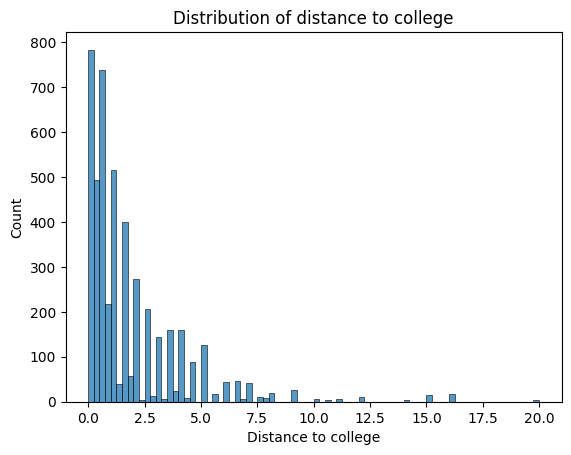

In [23]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.histplot(df['distance'])
plt.xlabel('Distance to college')
plt.title('Distribution of distance to college')
plt.show()

### Naive OLS regression

**Run the naive regression:**

$\text{income\_binary} = \beta_0 + \beta_1 \cdot \text{education} + u$

This is "naive" because education might be endogenous — unobserved factors (like ability or motivation) could affect both education and income.

In [25]:
from linearmodels import IV2SLS

formula = "income_binary ~ 1 + education"
mod = IV2SLS.from_formula(formula, df)
res = mod.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:          income_binary   R-squared:                      0.0480
Estimator:                        OLS   Adj. R-squared:                 0.0478
No. Observations:                4739   F-statistic:                    227.43
Date:                Sun, Mar 01 2026   P-value (F-stat)                0.0000
Time:                        16:13:01   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept     -0.4780     0.0499    -9.5702     0.0000     -0.5759     -0.3801
education      0.0555     0.0037     15.081     0.00

**Interpretation:** Education has a positive and significant effect on income. However, the R² is low — education alone explains only a small part of the variation in income.

**Augment the regression with `unemp`, `gender`, `ethnicity`, and `urban`.**

Categorical variables (like `gender` and `ethnicity`) are encoded automatically as dummy variables. One category is used as the **reference** (it is dropped from the regression).

In [26]:
# Check the available columns
df.columns

Index(['gender', 'ethnicity', 'score', 'fcollege', 'mcollege', 'home', 'urban',
       'unemp', 'wage', 'distance', 'tuition', 'education', 'income', 'region',
       'income_binary'],
      dtype='object')

In [41]:
formula = "income_binary ~ 1 + education + gender + ethnicity + urban + unemp"
mod = OLS.from_formula(formula, df)
res = mod.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:          income_binary   R-squared:                      0.0830
Estimator:                        OLS   Adj. R-squared:                 0.0818
No. Observations:                4739   F-statistic:                    456.93
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:57:46   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                                   Parameter Estimates                                   
                       Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------
Intercept                -0.4159     0.0538    -7.7362     0.0000     -0.5212     -0.3105
educatio

In [30]:
# Check which values ethnicity can take
df['ethnicity'].unique()

array(['other', 'afam', 'hispanic'], dtype=object)

The library automatically created dummy variables for categories. For the `ethnicity` variable, it used `afam` as the reference value.

We can change the reference value using the `C()` syntax. Let's use `other` as the reference:

In [42]:
# C(ethnicity, Treatment(reference='other')) tells the model to use 'other' as the baseline
formula = "income_binary ~ 1 + education + gender + C(ethnicity, Treatment(reference='other')) + urban + unemp"
mod = IV2SLS.from_formula(formula, df)
res = mod.fit()
print(res)

                            OLS Estimation Summary                            
Dep. Variable:          income_binary   R-squared:                      0.0830
Estimator:                        OLS   Adj. R-squared:                 0.0818
No. Observations:                4739   F-statistic:                    456.93
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        09:58:20   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                                                   Parameter Estimates                                                    
                                                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------------------------------------------

**Interpretation:**

- The Adjusted R² improved from the simple regression (now ~8%), but is still low.
- All coefficients are significant.
- The coefficient on education is stable compared to the simple regression, which is reassuring.

**Comment the results and explain the selection problem**

Even though the coefficient on education is significant, there might be **endogeneity**: unobserved factors (like ability, family background, motivation) could affect both the decision to get more education *and* income. If so, the OLS estimate is biased.

**Explain why distance to college might be used to instrument the effect of schooling.**

- **Relevance:** Students who live closer to a college are more likely to attend. So distance is correlated with education.
- **Exogeneity:** Assuming the family's location was not chosen based on college proximity, distance should not directly affect income (except through education).

These two conditions make distance a plausible instrument.

### IV regression

**Run an IV regression, where `distance` is used to instrument schooling.**

The syntax `[education ~ distance]` means: "instrument education with distance".

See: https://bashtage.github.io/linearmodels/ (two-stage least squares)

In [43]:
formula = "income_binary ~ 1 + [education ~ distance] + gender + C(ethnicity, Treatment(reference='other')) + urban + unemp"
mod = IV2SLS.from_formula(formula, df)
res = mod.fit()
print(res)

                          IV-2SLS Estimation Summary                          
Dep. Variable:          income_binary   R-squared:                     -0.2734
Estimator:                    IV-2SLS   Adj. R-squared:                -0.2750
No. Observations:                4739   F-statistic:                    213.68
Date:                Mon, Mar 02 2026   P-value (F-stat)                0.0000
Time:                        10:09:28   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                                                   Parameter Estimates                                                    
                                                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------------------------------------------

**Interpretation:**

The IV estimate for return on education is considerably **higher** than the OLS estimate. This suggests that the OLS estimate was biased (likely downward in this case). Using the instrument corrects for the endogeneity and reveals a stronger causal effect of education on income.

Compare your results with the R [tutorial](https://www.econometrics-with-r.org/12-6-exercises-10.html).